#### Mount to Google Drive

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/GenAI/"Final Project"

dino_file_check = os.path.exists("./dino_utils.py") and os.path.isfile("./dino_utils.py")
ir_file_check = os.path.exists("./ir_features_utils.py") and os.path.isfile("./ir_features_utils.py")
assert (dino_file_check and ir_file_check), "Not all files are present"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GenAI/Final Project


#### Install required libraries

In [2]:
!pip install -q diffusers matplotlib accelerate peft kornia open_clip_torch tqdm

# SISO Reimplemented

In [3]:
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers import (
    DDPMScheduler,
    DiffusionPipeline,
    AutoencoderKL,
    UNet2DConditionModel
)
from pipeline_stable_diffusion_xl_with_grads import StableDiffusionXLPipelineWithGrads
import torch
import torchvision
from peft import LoraConfig, get_peft_model
from accelerate import Accelerator
import matplotlib.pyplot as plt
from pprint import pprint
from tqdm import tqdm

import dino_utils as dino_utils
# import ir_features_utils as ir_features_utils

image_path = "./cat2.png"
accelerator = Accelerator()
device = accelerator.device

LR = 1E-3
ADAM_BETAS = (0.9, 0.999)
LORA_RANK = 32
LORA_ALPHA = 8

subject_image = torchvision.io.read_image(image_path).unsqueeze(0)

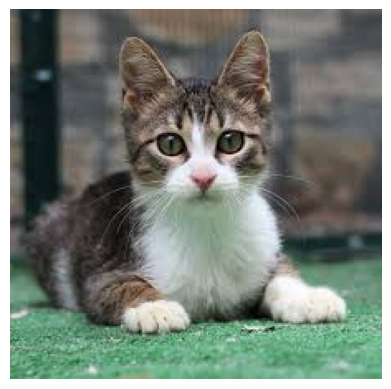

In [4]:
plt.imshow(torchvision.io.read_image(image_path).permute(1, 2, 0))
plt.axis('off')
plt.show()

In [5]:
model_path = "stabilityai/sdxl-turbo"

In [6]:
"""
  Refer to
    https://huggingface.co/docs/diffusers/en/training/lora
    https://github.com/huggingface/diffusers/blob/e4b8f173b97731686e290b2eb98e7f5df2b1b322/examples/text_to_image/train_text_to_image_lora.py

"""

noise_scheduler = DDPMScheduler.from_pretrained(model_path, subfolder="scheduler")
tokenizer = CLIPTokenizer.from_pretrained(model_path, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_path, subfolder="text_encoder")
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(model_path, subfolder="text_encoder_2")
unet = UNet2DConditionModel.from_pretrained(model_path, subfolder="unet")
vae = AutoencoderKL.from_pretrained(model_path, subfolder="vae")

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config)
# vae.add_adapter(lora_config)
lora_layers = list(filter(lambda p: p.requires_grad, unet.parameters()))

optimizer = torch.optim.AdamW(
    lora_layers,
    lr=LR,
    betas=ADAM_BETAS
)

unet, optimizer = accelerator.prepare(unet, optimizer)
# unet, vae, optimizer = accelerator.prepare(unet, vae, optimizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
# TODO: Implement IR feature
# See https://github.com/yairshp/SISO/blob/main/siso_generation_sdxl.py#L799-L827

dino_model_path = "vit_large_patch14_dinov2.lvd142m"
dino_criterion  = dino_utils.get_dino_features_negative_mean_cos_sim
dino, transforms_configs = (dino_utils.get_model_and_transforms_configs(dino_model_path))
dino_subject_image_input = dino_utils.prepare_for_dino(subject_image.float(), transforms_configs).cuda()
with torch.no_grad():
    dino_subject_image_features = dino_utils.get_dino_features(
        dino, dino_subject_image_input
    )

/content/drive/MyDrive/GenAI/Final Project/dino_utils.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_mean"]),
/content/drive/MyDrive/GenAI/Final Project/dino_utils.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(transforms_configs["normalize_std"]),


In [8]:
# TODO: Implement smarter stopping criteria
# Iterative Optimization
PYTORCH_CUDA_ALLOC_CONF=True
pipeline = StableDiffusionXLPipelineWithGrads.from_pretrained(
        model_path,
        vae=vae,
        text_encoder=text_encoder,
        text_encoder_2=text_encoder_2,
        unet=unet
    ).to(accelerator.device)

STOPPING_ITER = 30
prompt = "Image of cat"

first_image = None
best_loss = float("inf")
best_image = None

for iter in range(STOPPING_ITER):
    optimizer.zero_grad()
    generator = torch.Generator(device=accelerator.device)
    generator.manual_seed(42)

  # generate image
  # with accelerator.accumulate(unet):
    image = (pipeline(
                  prompt=prompt,
                  num_inference_steps=4,
                  output_type="pt",
                  height=512,
                  width=512,
                  generator=generator,
                  guidance_scale=0.0,
              )
              .images[0]
              .unsqueeze(0))
    # Save first image
    if iter == 0:
      first_image = image

    # calculate loss
    dino_loss = dino_criterion(
                      dino,
                      transforms_configs,
                      image,
                      dino_subject_image_features,
                  )
    loss = dino_loss    # TODO: add IR loss

    # save best loss/image
    if abs(loss.detach().item()) < abs(best_loss):
      best_loss = loss.detach().item()
      best_image = image

    # finetune model
    accelerator.backward(loss)
    optimizer.step()

    print(f"Loss {iter}: {loss.detach().item()}")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Loss 0: 0.006835177540779114


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 1: -0.02059841714799404


...

Loss 27: -0.1833154708147049


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 28: -0.20673926174640656


  0%|          | 0/4 [00:00<?, ?it/s]

Loss 29: -0.20216968655586243


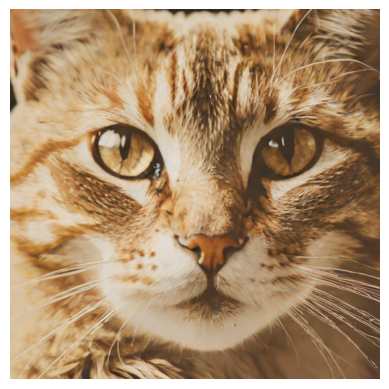

In [9]:
plt.imshow(first_image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()

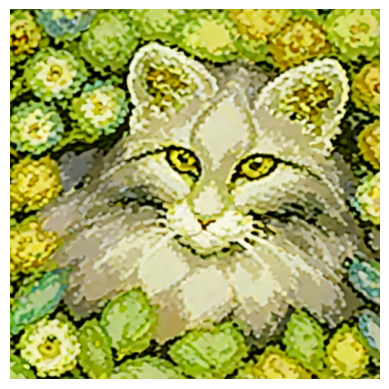

In [11]:
plt.imshow(image.detach().cpu().squeeze().permute(1,2,0))
plt.axis('off')
plt.show()